In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [30]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [31]:
housing_df = pd.concat([X, y.rename("MedHouseVal")], axis=1)
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [32]:
housing_df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [33]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [34]:
print('Shape of housing_df:', housing_df.shape)   
print('-'*100) 
print('Columns in housing_df:', housing_df.columns)   
print('-'*100) 
print('Summary statistics of housing_df:\n', housing_df.describe())   

Shape of housing_df: (20640, 9)
----------------------------------------------------------------------------------------------------
Columns in housing_df: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')
----------------------------------------------------------------------------------------------------
Summary statistics of housing_df:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%     

Analyzing column: MedInc
Skewness of MedInc: 1.6466567021344465
Skewness of log-transformed MedInc: 0.22608313067130548
----------------------------------------------------------------------------------------------------


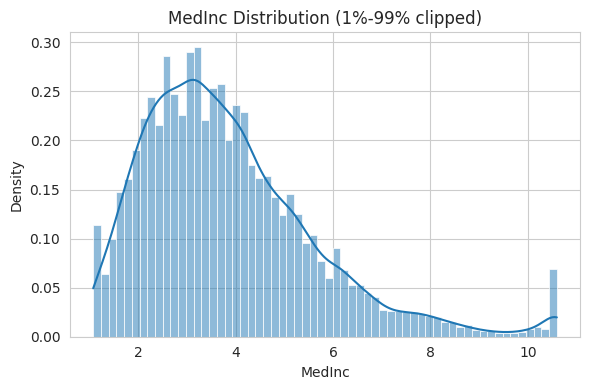

Analyzing column: HouseAge
Skewness of HouseAge: 0.06033063759913685
Skewness of log-transformed HouseAge: -1.1405705825482517
----------------------------------------------------------------------------------------------------


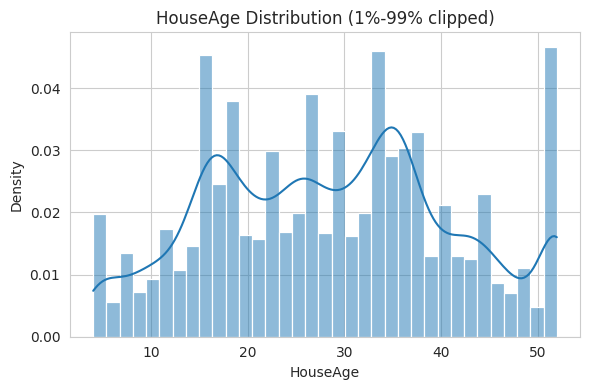

Analyzing column: AveRooms
Skewness of AveRooms: 20.69786895671065
Skewness of log-transformed AveRooms: 1.3907612222121986
----------------------------------------------------------------------------------------------------


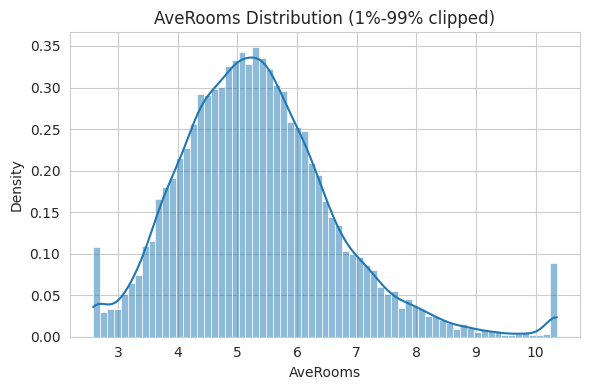

Analyzing column: AveBedrms
Skewness of AveBedrms: 31.316956246782674
Skewness of log-transformed AveBedrms: 8.988786093389576
----------------------------------------------------------------------------------------------------


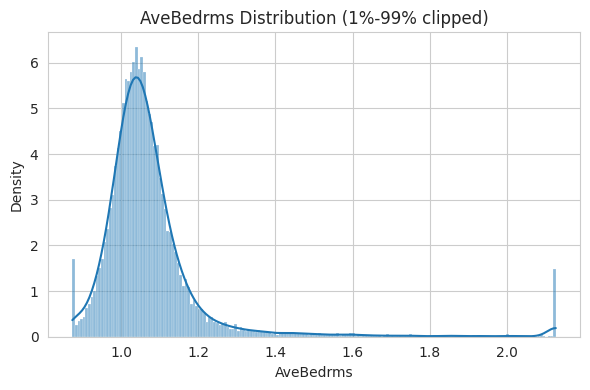

Analyzing column: Population
Skewness of Population: 4.935858226727124
Skewness of log-transformed Population: -1.0440866961519721
----------------------------------------------------------------------------------------------------


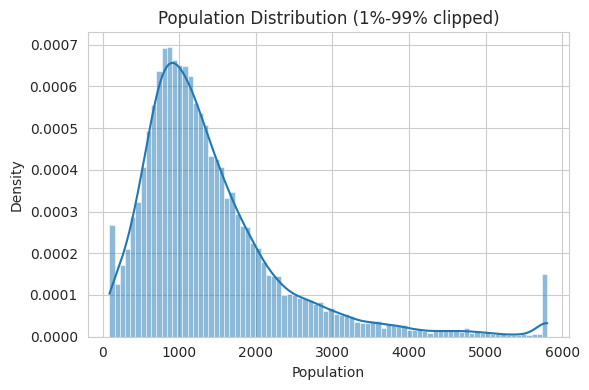

Analyzing column: AveOccup
Skewness of AveOccup: 97.63956096369486
Skewness of log-transformed AveOccup: 3.8796788829093227
----------------------------------------------------------------------------------------------------


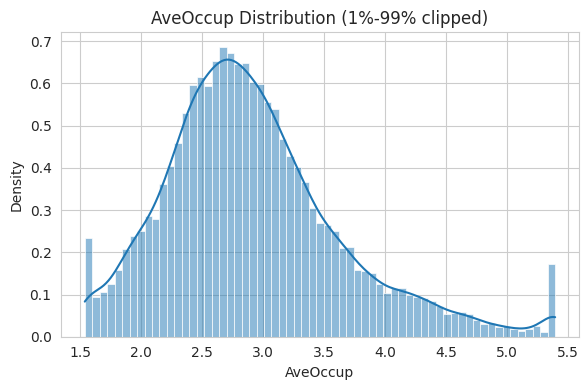

Analyzing column: Latitude
Skewness of Latitude: 0.4659530037099799
Skewness of log-transformed Latitude: 0.4111427541975552
----------------------------------------------------------------------------------------------------


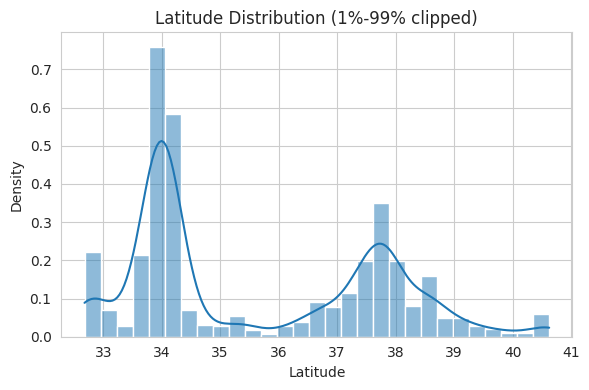

Analyzing column: Longitude
Skewness of Longitude: -0.2978012079524363
Longitude contains negative values → skipped log transform
----------------------------------------------------------------------------------------------------


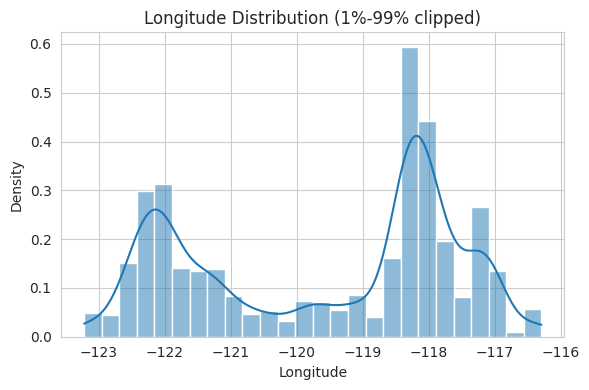

Analyzing column: MedHouseVal
Skewness of MedHouseVal: 0.9777632739098335
Skewness of log-transformed MedHouseVal: 0.2759390509171132
----------------------------------------------------------------------------------------------------


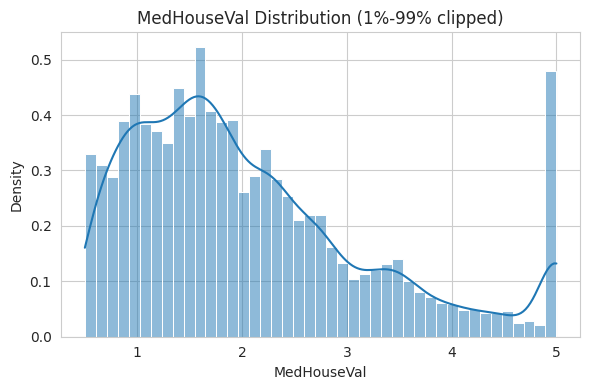

In [35]:
for column in housing_df.select_dtypes(include=np.number).columns:
    print(f'Analyzing column: {column}')
    
    print(f'Skewness of {column}: {housing_df[column].skew()}')

    if (housing_df[column] >= 0).all():
        y_log = np.log1p(housing_df[column])
        print(f'Skewness of log-transformed {column}: {y_log.skew()}')
    else:
        y_log = housing_df[column]
        print(f'{column} contains negative values → skipped log transform')

    print('-'*100)

    lower = housing_df[column].quantile(0.01)
    upper = housing_df[column].quantile(0.99)
    clipped = housing_df[column].clip(lower, upper)

    plt.figure(figsize=(6, 4))

    sns.histplot(
        clipped,
        bins="auto",         
        kde=True,
        stat="density"
    )

    plt.title(f'{column} Distribution (1%-99% clipped)')
    plt.xlabel(column)
    plt.ylabel('Density')

    plt.tight_layout()
    plt.show()

Analyzing column: MedInc
Skewness of MedInc: 1.6466567021344465
Skewness of log-transformed MedInc: 0.22608313067130548
----------------------------------------------------------------------------------------------------


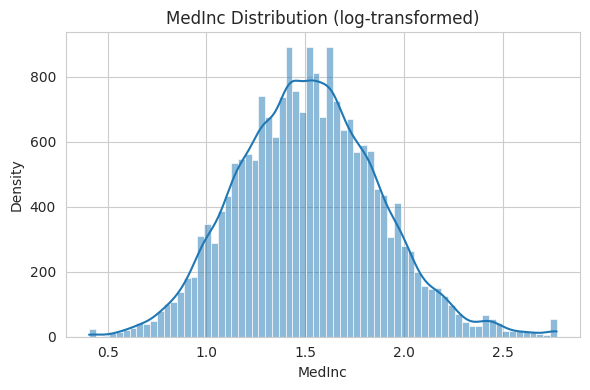

Analyzing column: HouseAge
Skewness of HouseAge: 0.06033063759913685
Skewness of log-transformed HouseAge: -1.1405705825482517
----------------------------------------------------------------------------------------------------


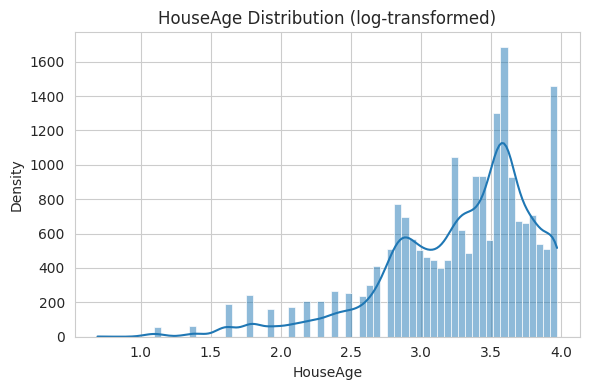

Analyzing column: AveRooms
Skewness of AveRooms: 20.69786895671065
Skewness of log-transformed AveRooms: 1.3907612222121986
----------------------------------------------------------------------------------------------------


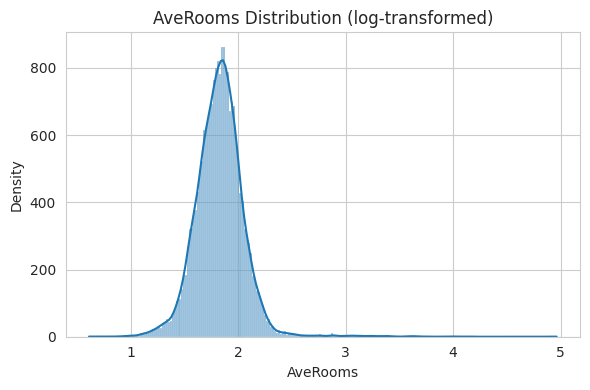

Analyzing column: AveBedrms
Skewness of AveBedrms: 31.316956246782674
Skewness of log-transformed AveBedrms: 8.988786093389576
----------------------------------------------------------------------------------------------------


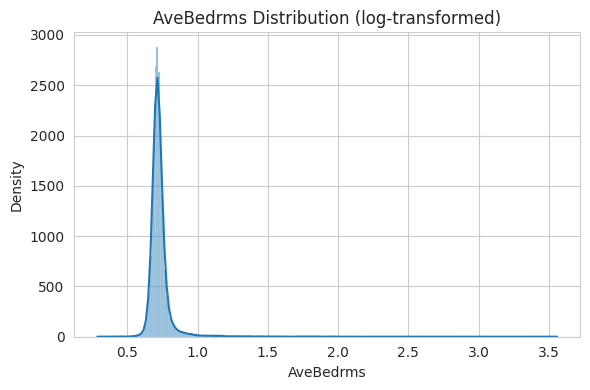

Analyzing column: Population
Skewness of Population: 4.935858226727124
Skewness of log-transformed Population: -1.0440866961519721
----------------------------------------------------------------------------------------------------


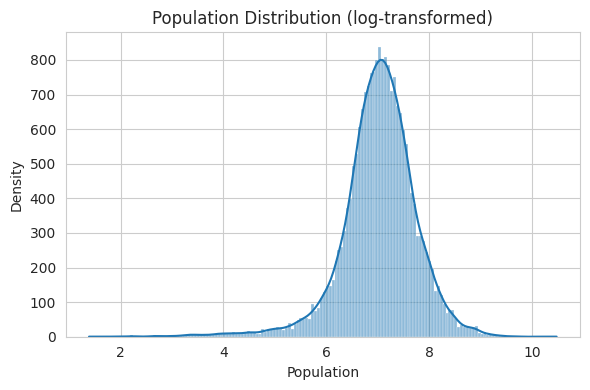

Analyzing column: AveOccup
Skewness of AveOccup: 97.63956096369486
Skewness of log-transformed AveOccup: 3.8796788829093227
----------------------------------------------------------------------------------------------------


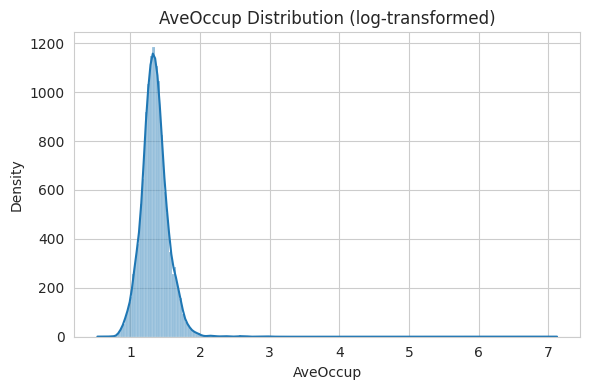

Analyzing column: Latitude
Skewness of Latitude: 0.4659530037099799
Skewness of log-transformed Latitude: 0.4111427541975552
----------------------------------------------------------------------------------------------------


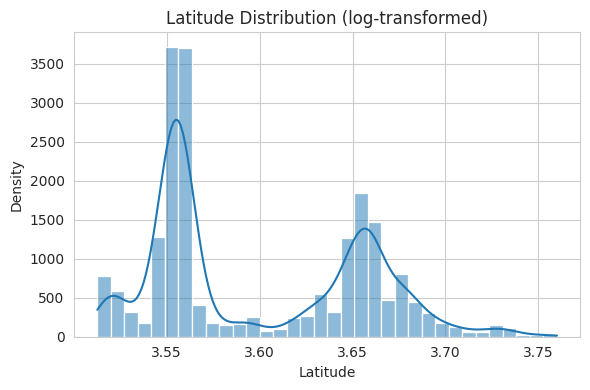

Analyzing column: Longitude
Skewness of Longitude: -0.2978012079524363
Longitude contains negative values → skipped log transform
----------------------------------------------------------------------------------------------------


/home/manheim666/.local/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


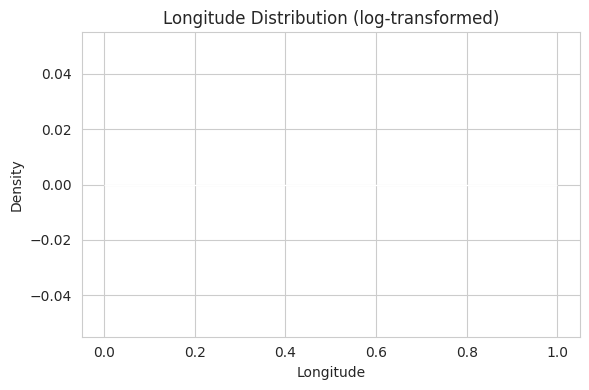

Analyzing column: MedHouseVal
Skewness of MedHouseVal: 0.9777632739098335
Skewness of log-transformed MedHouseVal: 0.2759390509171132
----------------------------------------------------------------------------------------------------


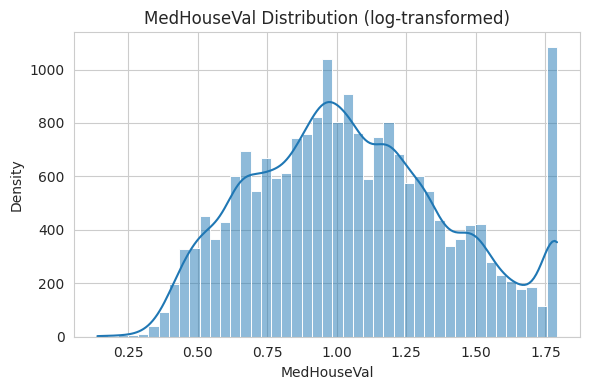

In [36]:
for column in housing_df.select_dtypes(include=np.number).columns:
    print(f'Analyzing column: {column}')
    
    print(f'Skewness of {column}: {housing_df[column].skew()}')

    if (housing_df[column] >= 0).all():
        y_log = np.log1p(housing_df[column])
        print(f'Skewness of log-transformed {column}: {y_log.skew()}')
    else:
        y_log = housing_df[column]
        print(f'{column} contains negative values → skipped log transform')

    print('-'*100)


    plt.figure(figsize=(6, 4))

    sns.histplot(np.log1p(housing_df[column]), bins="auto", kde=True)

    plt.title(f'{column} Distribution (log-transformed)')
    plt.xlabel(column)
    plt.ylabel('Density')

    plt.tight_layout()
    plt.show()

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f'Linear Regression\nMSE: {mse_lin:.4f}\nRMSE: {rmse_lin:.4f}\nMAE: {mae_lin:.4f}\nR²: {r2_lin:.4f}')


Linear Regression
MSE: 0.5559
RMSE: 0.7456
MAE: 0.5332
R²: 0.5758


## Linear Regression Results

The Linear Regression model was evaluated on the test set using multiple performance metrics.

- **Mean Squared Error (MSE):** 0.5559  
- **Root Mean Squared Error (RMSE):** 0.7456  
- **Mean Absolute Error (MAE):** 0.5332  
- **R² Score:** 0.5758  

### Interpretation

The R² score of **0.5758** indicates that the model explains approximately **57.6% of the variance** in the target variable (median house value).  

This suggests that while the linear model captures some relationship between features and house prices, a significant portion of the variance remains unexplained. This implies the presence of non-linear relationships or feature interactions that linear regression cannot fully capture.

Overall, this serves as a reasonable baseline, but more advanced models such as regularized regression or non-linear methods are expected to perform better.

In [38]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Why Feature Scaling is Important

Regularized models like Ridge and Lasso depend on the magnitude of coefficients. If features are on different scales, features with larger numeric ranges will dominate the penalty term.

StandardScaler ensures that:
- All features contribute equally
- Regularization is applied fairly across coefficients
- Gradient-based optimization becomes stable
- SVR also performs better due to distance-based computations

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.01, 0.1, 1, 10, 100]

# -------------------
# RIDGE
# -------------------
ridge_r2 = {}

best_ridge_model = None
best_ridge_score = -np.inf
best_ridge_alpha = None

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    ridge_r2[alpha] = r2

    if r2 > best_ridge_score:
        best_ridge_score = r2
        best_ridge_alpha = alpha
        best_ridge_model = ridge

print('Ridge Regression R² Scores:')
print(pd.Series(ridge_r2))
print()

# -------------------
# LASSO
# -------------------
lasso_r2 = {}

best_lasso_model = None
best_lasso_score = -np.inf
best_lasso_alpha = None

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    lasso_r2[alpha] = r2

    if r2 > best_lasso_score:
        best_lasso_score = r2
        best_lasso_alpha = alpha
        best_lasso_model = lasso

print('Lasso Regression R² Scores:')
print(pd.Series(lasso_r2))
print()

# -------------------
# BEST PREDICTIONS (CLEAN)
# -------------------
y_pred_ridge_best = best_ridge_model.predict(X_test_scaled)
y_pred_lasso_best = best_lasso_model.predict(X_test_scaled)

Ridge Regression R² Scores:
0.01      0.575788
0.10      0.575791
1.00      0.575816
10.00     0.576060
100.00    0.577791
dtype: float64

Lasso Regression R² Scores:
0.01      0.581615
0.10      0.481361
1.00     -0.000219
10.00    -0.000219
100.00   -0.000219
dtype: float64



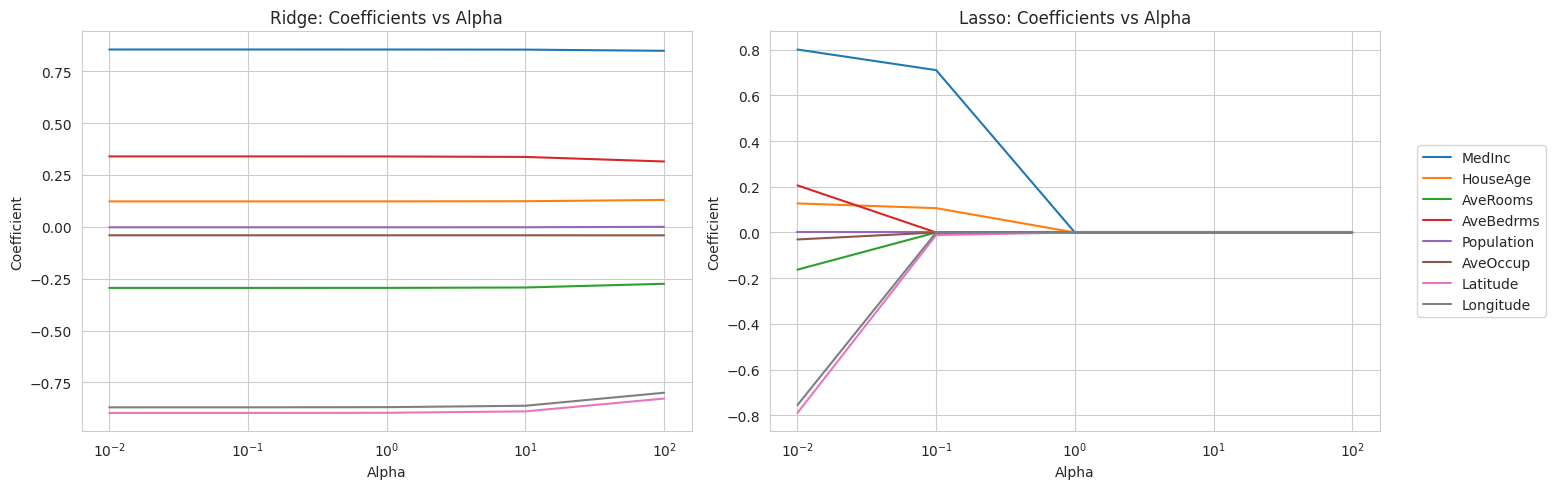

In [40]:
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
for i in range(len(X.columns)):
    axes[0].plot(alphas, ridge_coefs[:, i], label=X.columns[i])
axes[0].set_xscale("log")
axes[0].set_title("Ridge: Coefficients vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Coefficient")

# Lasso
for i in range(len(X.columns)):
    axes[1].plot(alphas, lasso_coefs[:, i], label=X.columns[i])
axes[1].set_xscale("log")
axes[1].set_title("Lasso: Coefficients vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Coefficient")

plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.show()

### Lasso Feature Selection Behavior

As alpha increases, Lasso forces more coefficients toward zero. This effectively removes less important features from the model.

In this dataset:
- Features like AveRooms and AveBedrms tend to shrink faster
- Population-related features may also reduce significantly
- Strong predictors like MedInc remain more stable

This shows that Lasso performs automatic feature selection, unlike Ridge which only shrinks coefficients.


## Ridge and Lasso Regression Results

### Ridge Regression R² Scores

- α = 0.01 → 0.5758  
- α = 0.10 → 0.5758  
- α = 1.00 → 0.5758  
- α = 10.00 → 0.5761  
- α = 100.00 → 0.5778  

**Interpretation:**  
Ridge regression shows very small changes in performance as the regularization strength increases. The R² values remain almost constant, indicating that Ridge mainly stabilizes the model without significantly affecting predictive power. This suggests that multicollinearity is present but not severe enough to strongly impact performance.

---

### Lasso Regression R² Scores

- α = 0.01 → 0.5816  
- α = 0.10 → 0.4814  
- α = 1.00 → -0.0002  
- α = 10.00 → -0.0002  
- α = 100.00 → -0.0002  

**Interpretation:**  
Lasso performs well at very small regularization (α = 0.01), but performance rapidly degrades as α increases. At higher values, the model collapses (R² ≈ 0 or negative), meaning it performs worse than predicting the mean.

This happens because strong Lasso regularization forces many coefficients to zero, leading to underfitting and loss of important predictive features.

In [48]:
svr_lin = SVR(kernel='linear')
svr_lin.fit(X_train_scaled, y_train)
y_pred_svr_lin = svr_lin.predict(X_test_scaled)
mse_svr_lin = mean_squared_error(y_test, y_pred_svr_lin)
rmse_svr_lin = np.sqrt(mse_svr_lin)
mae_svr_lin = mean_absolute_error(y_test, y_pred_svr_lin)
r2_svr_lin = r2_score(y_test, y_pred_svr_lin)
print(f'SVR (Linear Kernel)\nMSE: {mse_svr_lin:.4f}\nRMSE: {rmse_svr_lin:.4f}\nMAE: {mae_svr_lin:.4f}\nR²: {r2_svr_lin:.4f}')

SVR (Linear Kernel)
MSE: 0.5793
RMSE: 0.7611
MAE: 0.5120
R²: 0.5579


### Hyperparameter Tuning for SVR

Instead of manually testing combinations of C and epsilon, GridSearchCV is used.

GridSearchCV performs:
- Exhaustive search over parameter combinations
- 5-fold cross-validation
- Selection of the best model based on average R² score

This approach is more reliable and efficient than manual tuning.

In [49]:
param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 5, 7.5, 10],
    "epsilon": [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 1],
    "kernel": ["rbf"]
}

svr = SVR()

grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)


results_df = pd.DataFrame(grid_search.cv_results_)
results_clean = results_df[[
    "param_C",
    "param_epsilon",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]]

results_clean = results_clean.sort_values(by="mean_test_score", ascending=False)

results_clean.rename(columns={
    "param_C": "C",
    "param_epsilon": "epsilon",
    "mean_test_score": "CV_R2",
    "std_test_score": "std"
}, inplace=True)

print(results_clean)




print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)


best_svr = grid_search.best_estimator_

y_pred_svr_best = best_svr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_svr_best)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_svr_best)
r2 = r2_score(y_test, y_pred_svr_best)

print(f"SVR Test Performance")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Fitting 5 folds for each of 49 candidates, totalling 245 fits
        C  epsilon     CV_R2       std  rank_test_score
45  10.00     0.30  0.760312  0.004158                1
46  10.00     0.40  0.759765  0.004747                2
44  10.00     0.20  0.759589  0.003241                3
38   7.50     0.30  0.758716  0.004678                4
39   7.50     0.40  0.758374  0.004958                5
43  10.00     0.10  0.758325  0.003095                6
37   7.50     0.20  0.758219  0.003678                7
42  10.00     0.01  0.757741  0.003513                8
36   7.50     0.10  0.757208  0.003274                9
47  10.00     0.50  0.756904  0.005164               10
35   7.50     0.01  0.756349  0.003507               11
31   5.00     0.30  0.755790  0.004859               12
40   7.50     0.50  0.755614  0.005533               13
32   5.00     0.40  0.755606  0.005464               14
30   5.00     0.20  0.755583  0.004052               15
29   5.00     0.10  0.754854  0.003891    

In [43]:
pivot_table = results_clean.pivot(
    index="C",
    columns="epsilon",
    values="CV_R2"
)

print(pivot_table)

epsilon      0.01      0.10      0.20      0.30      0.40      0.50      1.00
C                                                                            
0.01     0.586002  0.585867  0.585045  0.583771  0.582562  0.578464  0.481023
0.10     0.692114  0.692913  0.693937  0.692827  0.690116  0.685218  0.593837
0.50     0.725970  0.726492  0.727709  0.728451  0.727779  0.724957  0.646089
1.00     0.736445  0.736810  0.738039  0.739152  0.738391  0.736187  0.663071
5.00     0.753443  0.754854  0.755583  0.755790  0.755606  0.752976  0.687619
7.50     0.756349  0.757208  0.758219  0.758716  0.758374  0.755614  0.691617
10.00    0.757741  0.758325  0.759589  0.760312  0.759765  0.756904  0.694495


In [44]:
svr_poly_2 = SVR(kernel='poly', degree=2)
svr_poly_2.fit(X_train_scaled, y_train)
y_pred_svr_poly_2 = svr_poly_2.predict(X_test_scaled)
mse_svr_poly_2 = mean_squared_error(y_test, y_pred_svr_poly_2)
rmse_svr_poly_2 = np.sqrt(mse_svr_poly_2)
mae_svr_poly_2 = mean_absolute_error(y_test, y_pred_svr_poly_2)
r2_svr_poly_2 = r2_score(y_test, y_pred_svr_poly_2)
print(f'SVR (Polynomial Kernel) of degree 2\nMSE: {mse_svr_poly_2:.4f}\nRMSE: {rmse_svr_poly_2:.4f}\nMAE: {mae_svr_poly_2:.4f}\nR²: {r2_svr_poly_2:.4f}')


svr_poly_3 = SVR(kernel='poly', degree=3)
svr_poly_3.fit(X_train_scaled, y_train)
y_pred_svr_poly_3 = svr_poly_3.predict(X_test_scaled)
mse_svr_poly_3 = mean_squared_error(y_test, y_pred_svr_poly_3)
rmse_svr_poly_3 = np.sqrt(mse_svr_poly_3)
mae_svr_poly_3 = mean_absolute_error(y_test, y_pred_svr_poly_3)
r2_svr_poly_3 = r2_score(y_test, y_pred_svr_poly_3)
print(f'SVR (Polynomial Kernel) of degree 3\nMSE: {mse_svr_poly_3:.4f}\nRMSE: {rmse_svr_poly_3:.4f}\nMAE: {mae_svr_poly_3:.4f}\nR²: {r2_svr_poly_3:.4f}')

SVR (Polynomial Kernel) of degree 2
MSE: 1.3842
RMSE: 1.1765
MAE: 0.7670
R²: -0.0563
SVR (Polynomial Kernel) of degree 3
MSE: 1.0036
RMSE: 1.0018
MAE: 0.5848
R²: 0.2341


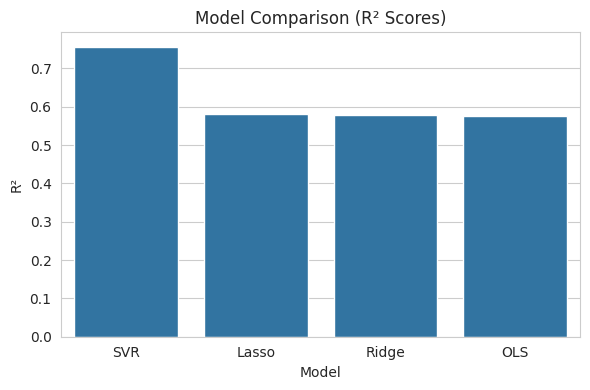

   Model       MSE      RMSE       MAE        R²
3    SVR  0.319304  0.565070  0.384480  0.756333
2  Lasso  0.548255  0.740442  0.535326  0.581615
1  Ridge  0.553266  0.743819  0.533014  0.577791
0    OLS  0.555892  0.745581  0.533200  0.575788


In [45]:
# -------------------
# OLS
# -------------------
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

# -------------------
# Best Ridge
# -------------------
best_ridge_alpha = max(ridge_r2, key=ridge_r2.get)
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = best_ridge.predict(X_test_scaled)

# -------------------
# Best Lasso
# -------------------
best_lasso_alpha = max(lasso_r2, key=lasso_r2.get)
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = best_lasso.predict(X_test_scaled)

# -------------------
# Best SVR (from GridSearch)
# -------------------
best_svr = grid_search.best_estimator_
y_pred_svr = best_svr.predict(X_test_scaled)


models = {
    "OLS": y_pred_ols,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "SVR": y_pred_svr
}

results = []

for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append([name, mse, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "MAE", "R²"])


plt.figure(figsize=(6,4))
sns.barplot(data=results_df.sort_values("R²", ascending=False),
            x="Model", y="R²")
plt.title("Model Comparison (R² Scores)")
plt.tight_layout()
plt.show()


print(results_df.sort_values(by="R²", ascending=False))

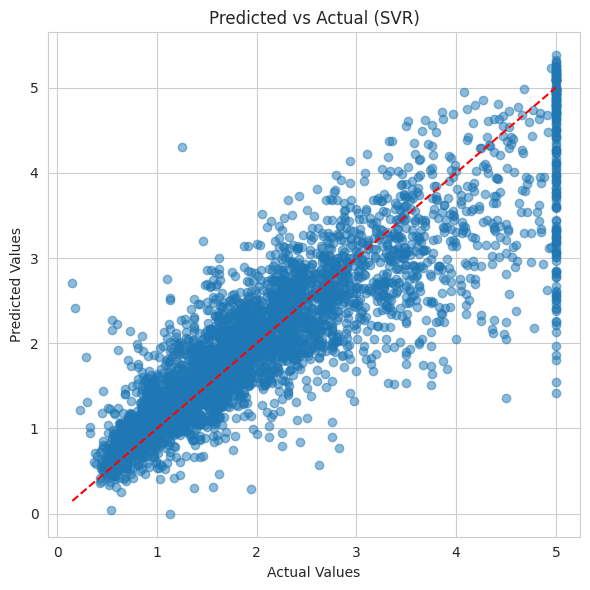

In [46]:
best_model_name = results_df.sort_values(by="R²", ascending=False).iloc[0]["Model"]

best_preds = {
    "OLS": y_pred_ols,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "SVR": y_pred_svr
}[best_model_name]

plt.figure(figsize=(6,6))

plt.scatter(y_test, best_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.title(f"Predicted vs Actual ({best_model_name})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.show()

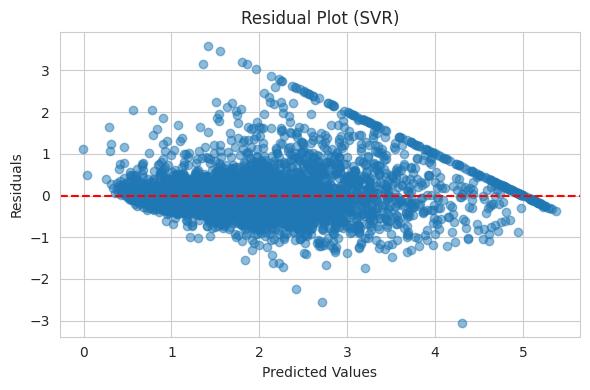

In [47]:
residuals = y_test - best_preds

plt.figure(figsize=(6,4))
plt.scatter(best_preds, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.title(f"Residual Plot ({best_model_name})")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

## Final Model Comparison and Conclusion

### Model Performance Summary

All models were evaluated using MSE, RMSE, MAE, and R² to compare predictive performance on the California Housing dataset.

| Model | MSE | RMSE | MAE | R² |
|------|------|------|------|------|
| SVR (best, RBF kernel) | 0.3193 | 0.5651 | 0.3845 | 0.7563 |
| Lasso | 0.5483 | 0.7404 | 0.5353 | 0.5816 |
| Ridge | 0.5533 | 0.7438 | 0.5330 | 0.5778 |
| OLS (Linear Regression) | 0.5559 | 0.7456 | 0.5332 | 0.5758 |

---

### Interpretation of Results

The results show a clear hierarchy in model performance:

- **SVR (RBF kernel)** achieved the best performance overall, significantly outperforming all linear models. This indicates that the relationship between features and housing prices is non-linear and better captured by flexible kernel methods.

- **Linear models (OLS, Ridge, Lasso)** performed similarly, with only minor differences in R² values. This suggests that linear relationships exist in the data but are limited in capturing full complexity.

- **Ridge regression** slightly improves stability over OLS by reducing coefficient variance, but does not significantly improve predictive accuracy.

- **Lasso regression** performs well only at low regularization strength. As alpha increases, performance drops sharply, indicating strong underfitting due to excessive feature elimination.

---

### Polynomial SVR Observation

- SVR with **degree 2 polynomial kernel** performed poorly (negative R²), indicating underfitting or poor suitability for this transformation.
- Degree 3 improved performance but still failed to match the RBF kernel.

---

### Key Insights

- The dataset contains **non-linear relationships**, making SVR (RBF) the most suitable model.
- Regularized linear models provide **stability and interpretability**, but limited expressive power.
- Lasso is useful for feature selection but can degrade performance if over-regularized.

---

### Final Conclusion

The best performing model is **SVR with RBF kernel**, as it achieves the highest R² and lowest error metrics.

However, if interpretability and simplicity are required, **Ridge regression is the best practical choice**, offering stable performance with minimal complexity.

In deployment scenarios, the choice depends on the goal:
- Choose **SVR** for maximum accuracy.
- Choose **Ridge** for a balance between performance and interpretability.